# Data set for donut

In [15]:
## load all file from dataset

import os
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pyarrow.dataset import dataset

total = 0
var = {"dataset_len": {
    "train": 0,
    "test": 0,
    "validation": 0,
    "total": 0
}}
for i in ["train", "test", "validation"]:
    var["dataset_len"]["total"] += len(os.listdir(f"dataset/{i}"))
    var["dataset_len"][i] = len(os.listdir(f"dataset/{i}"))

print(var)

{'dataset_len': {'train': 4258, 'test': 541, 'validation': 535, 'total': 5334}}


In [16]:
var["dataset_langs"] = ["Ceština", "Staročeština", "Němřina", "Latina", "Angličtina", "Italština", "Slovenština"]
# from LLM

In [28]:
import json
from typing import List, Dict, Any

def _calculate_max_depth_recursive(entry: Dict[str, Any], current_depth: int) -> int:
    max_depth_here = current_depth

    if 'children' in entry and isinstance(entry.get('children'), list) and entry['children']:
        for child in entry['children']:
            if isinstance(child, dict):
                child_depth = _calculate_max_depth_recursive(child, current_depth + 1)
                max_depth_here = max(max_depth_here, child_depth)

    return max_depth_here

def _collect_all_depths_recursive(entry: Any, current_depth: int) -> List[int]:
    if not isinstance(entry, dict):
        return []

    depths = [current_depth]

    children = entry.get('children')
    if isinstance(children, list) and children:
        for child in children:
            child_depths = _collect_all_depths_recursive(child, current_depth + 1)
            depths.extend(child_depths)

    return depths

def find_all_depths_from_file(filename: str) -> List[int]:
    all_found_depths: List[int] = []
    line_number = 0

    try:
        with open(filename, 'r', encoding='utf-8') as f:
            for line in f:
                line_number += 1
                try:
                    parsed_json = json.loads(line)

                    ground_truth_data = parsed_json.get('ground_truth')
                    if not isinstance(ground_truth_data, str):
                         print(f"Warning on line {line_number}: 'ground_truth' is not a string, skipping.")
                         continue

                    try:
                        ground_truth_parsed = json.loads(ground_truth_data)
                    except json.JSONDecodeError:
                         print(f"Warning on line {line_number}: Failed to parse JSON in 'ground_truth', skipping.")
                         continue

                    ground_truth_parse_data = ground_truth_parsed.get('gt_parse')
                    if not isinstance(ground_truth_parse_data, dict):
                         print(f"Warning on line {line_number}: 'gt_parse' is not a dictionary, skipping.")
                         continue

                    result_list = ground_truth_parse_data.get('result')
                    if not isinstance(result_list, list):
                        continue

                    for top_level_entry in result_list:
                        entry_depths = _collect_all_depths_recursive(top_level_entry, 1)
                        if max(entry_depths) > 5:
                            print(parsed_json["file_name"])
                        all_found_depths.extend(entry_depths)

                except json.JSONDecodeError:
                    print(f"Error: Invalid JSON on line {line_number}. Line skipped.")
                except KeyError as e:
                    print(f"Warning: Unexpected missing key '{e}' on line {line_number} even when using .get(). Line skipped.")
                except Exception as e:
                     print(f"Unexpected error on line {line_number}: {e}. Line skipped.")

    except FileNotFoundError:
        print(f"Error: File '{filename}' not found.")
        return []
    except Exception as e:
        print(f"Error opening or reading file: {e}")
        return []

    return all_found_depths

results = {}

results["total"] = 0

all_recursion = []
for dataset_type in ["train", "test", "validation"]:
    file_to_analyze = f'dataset/{dataset_type}/metadata.jsonl'

    depths = find_all_depths_from_file(file_to_analyze)
    results[dataset_type] = max(depths)

    all_recursion += depths

    results["max"] = max(max(depths), results["total"])

results

cce1220e-12dc-4693-afb9-be49507ee6cc.a1c7f1d1-854e-11ea-9487-001999480be2.215.None.uzei.jpg
68fd9c5e-ad83-4c53-b7ff-da6fce3fdaca.041784f2-e638-11ec-8919-001b63bd97ba.157.None.cuni.jpg
4587e6a2-7e93-4ca0-87b1-c2bb5d70ff01.f137eb6c-0087-11ea-9c22-00155d012102.3.None.svkhk.jpg
ac57757b-523e-42f6-b019-9e34ef9063bb.1a602bf4-6d9d-4683-bae7-d81d23d3bb45.11.None.cuni.jpg
b63c6517-79d6-4727-ac37-6f27b6b6bd2f.9a27b869-e23f-11e6-b177-001999480be2.9.None.uzei.jpg


{'total': 0, 'train': 6, 'max': 6, 'test': 6, 'validation': 6}

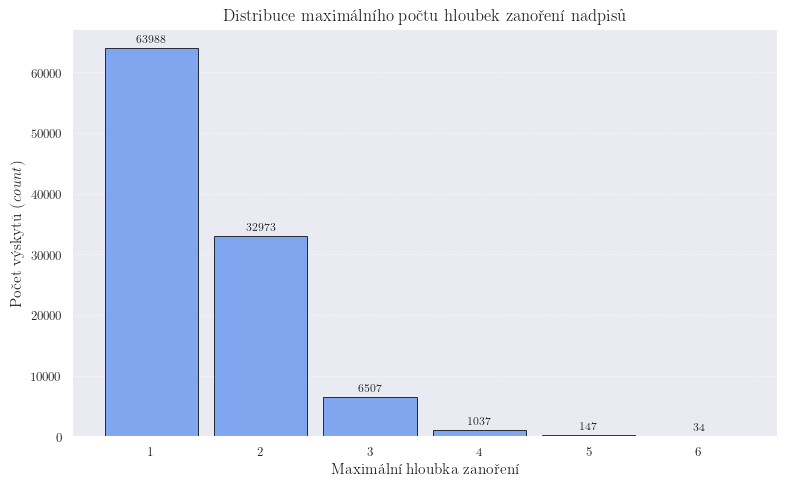

Graph saved as distribuce_maximálního_počtu_hloubek_zanoření_nadpisů.pdf


In [30]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib
from collections import Counter  # For easier counting of each bin

use_latex = True

# --- LaTeX Configuration ---
plt.rcParams.update({
    "text.usetex": use_latex,
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman", "Times New Roman", "DejaVu Serif"],
    "font.size": 11,
    "axes.labelsize": 11,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 10,
    "axes.titlesize": 12,
    "axes.linewidth": 0.8,
    "grid.linewidth": 0.5,
    "lines.linewidth": 1.0,
    "patch.edgecolor": 'black',  # Column border color
    "patch.linewidth": 0.7,
})

if use_latex:
    plt.rcParams['text.latex.preamble'] = r"""
        \usepackage[utf8]{inputenc}
        \usepackage[T1]{fontenc}
        \usepackage{amsmath}
        \usepackage{amsfonts}
        \usepackage{amssymb}
        \usepackage[czech]{babel}  % Czech labels, if needed
    """

# --- Histogram Plotting Function ---

def plot_depth_histogram(depths_list: list[int], title: str = "Histogram hloubek nadpisů"):
    """
    Plots a histogram of heading depths with customization options.

    Args:
        depths_list: List of integer heading depths.
        title: Title of the plot.
    """

    if not depths_list:
        print("Warning: Empty depths list. No histogram will be generated.")
        return

    min_depth = min(depths_list)
    max_depth = max(depths_list)
    bin_edges = np.arange(min_depth - 0.5, max_depth + 1.5, 1)

    fig, ax = plt.subplots(figsize=(8, 5))

    counts, edges, patches = ax.hist(
        depths_list,
        bins=bin_edges,
        color='cornflowerblue',
        alpha=0.8,
        rwidth=0.85
    )

    tick_locations = np.arange(min_depth, max_depth + 1)
    ax.set_xticks(tick_locations)
    ax.set_xticklabels([str(int(loc)) for loc in tick_locations])

    xlabel = r'Maximální hloubka zanoření' if use_latex else 'Hloubka zanoření (depth)'
    ylabel = r'Počet výskytů (\textit{count})' if use_latex else 'Počet výskytů (count)'
    plot_title = title

    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)  # Added y-axis label
    ax.set_title(plot_title)

    ax.yaxis.grid(True, linestyle='--', linewidth=plt.rcParams['grid.linewidth'], alpha=0.6)
    ax.xaxis.grid(False)

    bin_centers = 0.5 * (edges[:-1] + edges[1:])
    max_count = max(counts) if counts.size > 0 else 1 # Prevent division by zero if counts is empty
    for count, x_pos in zip(counts, bin_centers):
        if count > 0:
            ax.text(x_pos, count + max_count*0.01, str(int(count)), ha='center', va='bottom', fontsize=8)

    plt.tight_layout()

    plt.show()

    safe_title = title.lower().replace(" ", "_").replace("\\", "") + ".pdf" # Fixed potential error in filename
    fig.savefig(safe_title, format='pdf', bbox_inches='tight')
    print(f"Graph saved as {safe_title}")

# Example usage:
plot_depth_histogram(all_recursion, title="Distribuce maximálního počtu hloubek zanoření nadpisů")

/home/jvlk/miniconda3/envs/general/lib/python3.12/site-packages/huggingface_hub/file_download.py:797: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
2025-04-04 17:53:04,572 - INFO - Tokenizer 'naver-clova-ix/donut-base' successfully loaded.
2025-04-04 17:53:04,573 - INFO - Processing file: dataset/train/metadata.jsonl
2025-04-04 17:53:08,042 - INFO - File dataset/train/metadata.jsonl: Processed 4257 valid lines.
2025-04-04 17:53:08,043 - INFO - Processing file: dataset/test/metadata.jsonl
2025-04-04 17:53:08,462 - INFO - File dataset/test/metadata.jsonl: Processed 540 valid lines.
2025-04-04 17:53:08,463 - INFO - Processing file: dataset/validation/metadata.jsonl
2025-04-04 17:53:08,868 - INFO - File dataset/validation/metadata.jsonl: Processed 533 valid lines.
2025-04-04 17:53:08,870 - INFO - Total processed 5330 valid records.
2

Histogram saved to file: 'token_count_histogram.pdf'


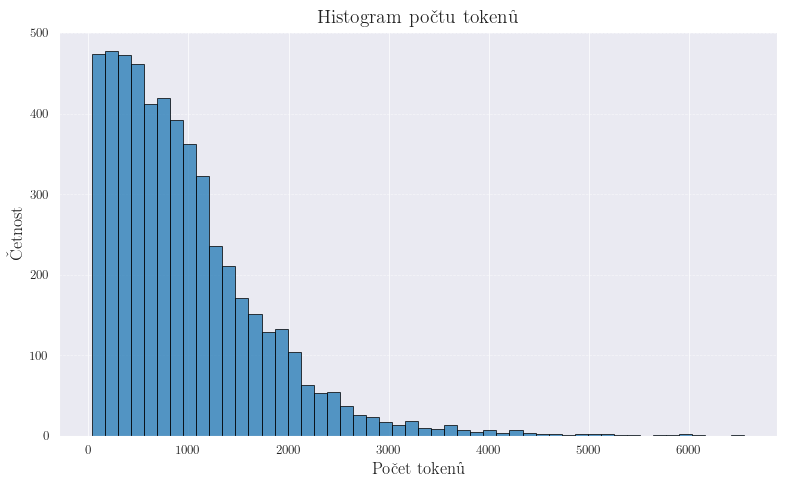

In [31]:
import json
import os
from transformers import AutoTokenizer
from typing import List, Dict, Any, Tuple
import logging
import matplotlib
import pandas as pd
import matplotlib.pyplot as plt

use_latex= True
# --- LaTeX Configuration ---
plt.rcParams.update({
    "text.usetex": use_latex,
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman", "Times New Roman", "DejaVu Serif"],
    "font.size": 11,
    "axes.labelsize": 11,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 10,
    "axes.titlesize": 12,
    "axes.linewidth": 0.8,
    "grid.linewidth": 0.5,
    "lines.linewidth": 1.0,
    "patch.edgecolor": 'black', # Column border color
    "patch.linewidth": 0.7,
})
# If you need specific LaTeX packages (e.g., for Czech, mathematics)
if use_latex:
    plt.rcParams['text.latex.preamble'] = r"""
        \usepackage[utf8]{inputenc}
        \usepackage[T1]{fontenc}
        \usepackage{amsmath}
        \usepackage{amsfonts}
        \usepackage{amssymb}
        % Add other packages as needed
    """

# Setting up logging for better tracking of potential errors
logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')

# --- Function to calculate depth (from previous response - not necessary for tokenization) ---
def _calculate_max_depth_recursive(entry: Dict[str, Any], current_depth: int) -> int:
    max_depth_here = current_depth
    if 'children' in entry and isinstance(entry.get('children'), list) and entry['children']:
        for child in entry['children']:
            if isinstance(child, dict):
                child_depth = _calculate_max_depth_recursive(child, current_depth + 1)
                max_depth_here = max(max_depth_here, child_depth)
    return max_depth_here

def find_max_structure_depth(result_list: List[Dict[str, Any]]) -> int:
     """Calculates the maximum structure depth in the 'result' list."""
     if not result_list:
         return 0
     current_max_depth = 0
     for top_level_entry in result_list:
         if isinstance(top_level_entry, dict):
             entry_max_depth = _calculate_max_depth_recursive(top_level_entry, 1)
             current_max_depth = max(current_max_depth, entry_max_depth)
     return current_max_depth
# --- End of depth functions ---


def get_max_tokens_for_ground_truth(filenames: List[str], tokenizer_name: str = "bert-base-multilingual-cased") -> (int, int):
    """
    Loads JSON Lines files, extracts, parses, and tokenizes the content of 'ground_truth' -> 'gt_parse' -> 'result'
    and finds the maximum number of tokens and the maximum structure depth.

    Args:
        filenames: List of paths to JSON Lines files.
        tokenizer_name: Name of the tokenizer from Hugging Face Hub.

    Returns:
        Tuple: (maximum number of tokens, maximum structure depth) found in all files.
               Returns (0, 0) if no data can be processed.
    """
    try:
        tokenizer = AutoTokenizer.from_pretrained(tokenizer_name)
        logging.info(f"Tokenizer '{tokenizer_name}' successfully loaded.")
    except Exception as e:
        logging.error(f"Error loading tokenizer '{tokenizer_name}': {e}")
        logging.error("Make sure you have the 'transformers' library installed and a valid tokenizer name.")
        return 0, 0

    overall_max_tokens = 0
    overall_max_depth = 0
    processed_lines_count = 0

def analyze_token_counts(filenames: List[str], tokenizer_name: str = "bert-base-multilingual-cased") -> Tuple[pd.DataFrame, int, int]:
    """
    Loads JSON Lines files, extracts, parses, and tokenizes the content of
    'ground_truth' -> 'gt_parse' -> 'result', collects all token counts
    into a DataFrame, and finds the maximum token count and maximum depth.

    Args:
        filenames: List of paths to JSON Lines files.
        tokenizer_name: Name of the tokenizer from Hugging Face Hub.

    Returns:
        Tuple: (Pandas DataFrame with token counts, maximum token count, maximum structure depth).
               Returns (empty DataFrame, 0, 0) if no data can be processed.
    """
    try:
        tokenizer = AutoTokenizer.from_pretrained(tokenizer_name)
        logging.info(f"Tokenizer '{tokenizer_name}' successfully loaded.")
    except Exception as e:
        logging.error(f"Error loading tokenizer '{tokenizer_name}': {e}")
        return pd.DataFrame(columns=['token_count']), 0, 0

    all_token_counts = [] # List to collect token counts
    overall_max_tokens = 0
    overall_max_depth = 0
    processed_lines_count = 0
    processed_files_count = 0

    for filename in filenames:
        logging.info(f"Processing file: {filename}")
        if not os.path.exists(filename):
            logging.warning(f"File '{filename}' does not exist, skipping.")
            continue

        processed_files_count += 1
        line_number = 0
        file_processed_lines = 0
        try:
            with open(filename, 'r', encoding='utf-8') as f:
                for line in f:
                    line_number += 1
                    try:
                        # 1. Parsing the outer JSON (entire line)
                        outer_json = json.loads(line)

                        # 2. Getting the 'ground_truth' string
                        gt_string = outer_json.get('ground_truth')
                        if not isinstance(gt_string, str):
                            continue

                        # 3. Parsing the inner JSON (content of 'ground_truth')
                        try:
                            inner_json = json.loads(gt_string)
                        except json.JSONDecodeError:
                            continue

                        # 4. Extracting 'gt_parse' -> 'result'
                        gt_parse_dict = inner_json.get('gt_parse')
                        if not isinstance(gt_parse_dict, dict):
                            continue
                        result_list = gt_parse_dict.get('result')
                        if not isinstance(result_list, list):
                            continue

                        # Counting depth
                        current_depth = find_max_structure_depth(result_list)
                        overall_max_depth = max(overall_max_depth, current_depth)

                        # 5. Converting 'result' back to a compact JSON string
                        json_representation = json.dumps(result_list, ensure_ascii=False, separators=(',', ':'))

                        # 6. Tokenization
                        tokens = tokenizer.encode(json_representation, add_special_tokens=True)

                        # 7. Getting the token count
                        token_count = len(tokens)

                        # ---> 8. STORING TOKEN COUNT IN THE LIST <---
                        all_token_counts.append(token_count)

                        # 9. Updating the token maximum
                        overall_max_tokens = max(overall_max_tokens, token_count)
                        processed_lines_count += 1
                        file_processed_lines +=1


                    except json.JSONDecodeError:
                        logging.error(f"JSON parsing error on line {line_number} in {filename}. Skipping.")
                    except KeyError as e:
                        logging.error(f"Missing key '{e}' on line {line_number} in {filename}. Skipping.")
                    except Exception as e:
                        logging.error(f"Unexpected error on line {line_number} in {filename}: {e}. Skipping.")

            logging.info(f"File {filename}: Processed {file_processed_lines} valid lines.")

        except Exception as e:
            logging.error(f"Error reading file {filename}: {e}")

    if processed_files_count == 0:
        logging.warning("No existing files found to process.")
        return pd.DataFrame(columns=['token_count']), 0, 0

    if processed_lines_count == 0:
         logging.warning("No valid lines were processed. Check the file format.")
         return pd.DataFrame(columns=['token_count']), 0, 0 # Returning an empty DataFrame

    # ---> CREATING DATAFRAME <---
    df = pd.DataFrame(all_token_counts, columns=['token_count'])
    logging.info(f"Total processed {processed_lines_count} valid records.")

    return df, overall_max_tokens, overall_max_depth


def plot_token_histogram(df: pd.DataFrame, tokenizer_name: str = "Unknown Tokenizer", bins: int | str = 'auto', output_filename: str | None = None):
    """
    Plots a histogram from a DataFrame containing token counts.

    Args:
        df: Pandas DataFrame with at least one column 'token_count'.
        tokenizer_name: Name of the tokenizer for the graph title.
        bins: Number of histogram bins or strategy ('auto', 'sqrt', etc.).
              Default is 'auto'. You can also specify an integer.
        output_filename: Optional filename to save the graph (e.g., "histogram.png").
                         If None, the graph is not saved.
    """
    if df.empty or 'token_count' not in df.columns:
        logging.warning("DataFrame is empty or does not contain the 'token_count' column. Histogram cannot be plotted.")
        print("DataFrame is empty or does not contain the 'token_count' column.")
        return

    token_counts = df['token_count']

    plt.figure(figsize=(8, 5)) # Setting image size

    # Automatic calculation of bins if no number is given
    if isinstance(bins, str) and bins == 'auto':
         # Simple estimate - can be adjusted as needed
         n_unique = token_counts.nunique()
         calculated_bins = min(50, n_unique) if n_unique > 1 else 10
         plot_bins = calculated_bins
    elif isinstance(bins, int):
        plot_bins = bins
    else: # Fallback for other string values or invalid types
        plot_bins = 50 # Or another default value
        logging.warning(f"Invalid value for 'bins': {bins}. Using default count of 50.")


    plt.hist(token_counts, bins=plot_bins, edgecolor='black', alpha=0.75)

    plt.title(f'Histogram počtu tokenů', fontsize=14)
    plt.xlabel('Počet tokenů', fontsize=12)
    plt.ylabel('Četnost', fontsize=12)
    plt.grid(axis='y', linestyle='--', alpha=0.6) # Grid for better readability
    plt.tight_layout() # Automatically adjusts margins to fit labels

    # Saving the graph if a filename is given
    if output_filename:
        try:
            plt.savefig(output_filename, dpi=300) # Saving in higher resolution
            logging.info(f"Histogram saved to file: '{output_filename}'")
            print(f"Histogram saved to file: '{output_filename}'")
        except Exception as e:
            logging.error(f"Failed to save histogram to '{output_filename}': {e}")
            print(f"Error saving histogram: {e}")

    plt.show() # Showing the graph

# --- Main part of the script ---

# Assumed folder structure and filenames
dataset_base = 'dataset'
splits = ["train", "test", "validation"]
files_to_process = [os.path.join(dataset_base, split, 'metadata.jsonl') for split in splits]


tokenizer_to_use = "naver-clova-ix/donut-base"

df, max_tokens, max_depth = analyze_token_counts(files_to_process, tokenizer_to_use)

var["max_tokens"] = max_tokens

plot_token_histogram(df, tokenizer_name=tokenizer_to_use, bins='500', output_filename='token_count_histogram.pdf')

In [32]:
import os
from PIL import Image
import statistics  # median

def analyze_image_dimensions_median(folder_path):
    # Verify if the folder exists
    if not os.path.isdir(folder_path):
        print(f"Error: Folder '{folder_path}' not found.")
        return

    print(f"Analyzing image dimensions (min, max, median) in folder: {folder_path}\n" + "="*60)

    # Supported image extensions
    supported_extensions = ('.png', '.jpg', '.jpeg', '.bmp', '.gif', '.tif', '.tiff')

    widths = []
    heights = []
    image_count = 0

    for filename in os.listdir(folder_path):
        file_path = os.path.join(folder_path, filename)

        if os.path.isfile(file_path) and filename.lower().endswith(supported_extensions):
            try:
                with Image.open(file_path) as img:
                    width, height = img.size
                    print(f"File: {filename} -> Dimensions: {width}x{height}")
                    widths.append(width)
                    heights.append(height)
                    image_count += 1
            except Exception as e:
                print(f"  Error reading dimensions of file {filename}: {e}")

    print("="*60)

    if image_count > 0:
        # Sorting is not necessary for the median() function, but it's good to know that it does this internally
        # widths.sort()
        # heights.sort()

        min_width = min(widths)
        max_width = max(widths)
        median_width = statistics.median(widths)  # Calculate median width

        min_height = min(heights)
        max_height = max(heights)
        median_height = statistics.median(heights)  # Calculate median height

        print(f"Found and processed images: {image_count}")
        print("\n--- Width ---")
        print(f"  Minimum: {min_width} px")
        print(f"  Maximum: {max_width} px")
        # Median can be a decimal number (if there is an even number of elements),
        # so we display it without specific formatting to whole pixels
        print(f"  Median: {median_width} px")

        print("\n--- Height ---")
        print(f"  Minimum: {min_height} px")
        print(f"  Maximum: {max_height} px")
        print(f"  Median: {median_height} px")

    else:
        print("No supported images were found in the folder.")

    print("="*60 + "\nProcessing completed.")


folder_to_scan = "dataset/train"  # !!! CHANGE THIS !!!


# Run analysis
analyze_image_dimensions_median(folder_to_scan)

Analyzing image dimensions (min, max, median) in folder: dataset/train
File: 762eb582-35eb-4a1a-903b-0ed99ee77ca8.6306420e-3f91-4137-a2e4-307ca6af6996.202.None.npmk.jpg -> Dimensions: 1500x2119
File: 4a050adb-63bb-4b36-851e-a9c1a83ea2ce.01f154ef-5ba6-4bd8-b684-68d5991e947b.1.None.nlk.jpg -> Dimensions: 1349x2000
File: 05044e06-3368-41e0-bdca-c1340fcddd35.ee484faa-4c96-4505-a68b-96dfa5409a50.114.None.uzei.jpg -> Dimensions: 2287x3000
File: 2f1966bc-9537-4fef-a00d-c6f522a2ee08.7.1faab7c7-1037-4283-b1b8-44f02b4e2b36.jpg -> Dimensions: 2441x3226
File: c8801a83-e327-4887-95bc-749ed4aa42cd.157.1ef2e97e-4b24-4bca-959e-28068de081ab.jpg -> Dimensions: 1500x2650
File: bbb159d5-bd8b-41d0-88e8-6fc37f58489a.176d53d2-23ba-4602-967c-3372962d8234.3.None.nlk.jpg -> Dimensions: 1527x2241
File: 64276759-4b13-4b0b-b4eb-2ee93ded8d90.8c93f4ad-1b23-11e5-995e-00155d010f03.1104.None.svkhk.jpg -> Dimensions: 1936x2433
File: 6907131d-8f2f-435e-997b-79d812016db4.1ff2bdbd-fc66-4bd3-b47f-df0549441dbc.1.None.nlk.jpg

In [22]:
var

{'dataset_len': {'train': 4258, 'test': 541, 'validation': 535, 'total': 5334},
 'dataset_langs': ['Ceština',
  'Staročeština',
  'Němřina',
  'Latina',
  'Angličtina',
  'Italština',
  'Slovenština'],
 'max_recursion': {'total': 0,
  'train': 6,
  'max': 6,
  'test': 6,
  'validation': 6},
 'max_tokens': 6556}